In [6]:
# !pip install enlighten
# !pip install pint

In [7]:
import time
from collections import OrderedDict

import enlighten
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from pint import UnitRegistry
from shapely.geometry import LineString, MultiLineString, box
from shapely.ops import clip_by_rect, linemerge, unary_union
from skfem import Basis, ElementTriP0, Functional
from skfem.helpers import inner
from skfem.io.meshio import from_meshio

from femwell.maxwell.waveguide import (
    calculate_overlap,
    calculate_scalar_product,
    compute_modes,
)
from femwell.mesh import mesh_from_OrderedDict
from femwell.visualization import plot_domains

%matplotlib inline
# To make things go smoother I advise to use %matplotlib widget so that you can inspect the mesh and other figures more clearly

In [8]:
reg = UnitRegistry()

# Define frequency range
freq = np.linspace(0.2, 45, 10) * reg.GHz
omega = 2 * np.pi * freq

In [9]:
## Define universal constants
mu0 = 4 * np.pi * 1e-7 * reg.henry / reg.meter  # vacuum magnetic permeability
e0 = 8.854e-12 * reg.farad * reg.meter**-1
c = 3e8 * reg.meter * reg.second**-1  # m s^-1
e = 1.602176634e-19 * reg.coulomb  # Coulombs
kb = 1.380649e-23 * reg.meter**2 * reg.kg * reg.second**-2 * reg.kelvin**-1
T = 300 * reg.kelvin

In [10]:
w_sig = 7 * reg.micrometer
sep = 10 * reg.micrometer
w_gnd = 100 * reg.micrometer
t_metal = 0.8 * reg.micrometer

port_width = (w_sig + 2 * sep + 2 * w_gnd) * 0.5 + 10 * reg.micrometer  # um
bottom_height = 100 * reg.micrometer
top_height = 100 * reg.micrometer


eps_r_sub = 13 * reg.dimensionless  # substrate relative permitivity
sig_metal = 6e5 * reg.siemens / reg.centimeter  # Metal conductivity

In [11]:
######## Define FEM simulation ###########
use_symmetry_plane = True * 0
symmetry_plane = box(0, -np.inf, np.inf, np.inf)

near_field_width = 50 * reg.micrometer
near_field_height = 10 * reg.micrometer
##########################################

metal_sig_box = box(
    -w_sig.to(reg.micrometer).magnitude / 2,
    0,
    w_sig.to(reg.micrometer).magnitude / 2,
    t_metal.to(reg.micrometer).magnitude,
)

metal_gnd_left_box = box(
    max(
        (-w_sig / 2 - sep - w_gnd).to(reg.micrometer).magnitude,
        -(port_width / 2).to(reg.micrometer).magnitude,
    ),
    0,
    (-w_sig / 2 - sep).to(reg.micrometer).magnitude,
    t_metal.to(reg.micrometer).magnitude,
)

metal_gnd_right_box = box(
    (w_sig / 2 + sep).to(reg.micrometer).magnitude,
    0,
    min(
        (w_sig / 2 + sep + w_gnd).to(reg.micrometer).magnitude,
        (port_width / 2).to(reg.micrometer).magnitude,
    ),
    t_metal.to(reg.micrometer).magnitude,
)


air_box = box(
    (-port_width / 2).to(reg.micrometer).magnitude,
    0,
    (port_width / 2).to(reg.micrometer).magnitude,
    top_height.to(reg.micrometer).magnitude,
)


substrate_box = box(
    (-port_width / 2).to(reg.micrometer).magnitude,
    -(bottom_height).to(reg.micrometer).magnitude,
    (port_width / 2).to(reg.micrometer).magnitude,
    0,
)

surface = unary_union([air_box, substrate_box])

##Make a line for a path integral
### Right conductor
xmin_1, ymin_1, xmax_1, ymax_1 = metal_sig_box.bounds
xmin_2, ymin_2, xmax_2, ymax_2 = metal_gnd_right_box.bounds

points = [
    ((xmax_1 + xmin_1) / 2, (ymax_1 + ymin_1) / 2),
    (xmax_1, (ymax_1 + ymin_1) / 2),
    (xmin_2, (ymax_2 + ymin_2) / 2),
    ((xmax_2 + xmin_2) / 2, (ymax_2 + ymin_2) / 2),
]

path_integral_right = LineString(points)

### left conductor
xmin_1, ymin_1, xmax_1, ymax_1 = metal_sig_box.bounds
xmin_2, ymin_2, xmax_2, ymax_2 = metal_gnd_left_box.bounds

points = [
    ((xmax_1 + xmin_1) / 2, (ymax_1 + ymin_1) / 2),
    (xmin_1, (ymax_1 + ymin_1) / 2),
    (xmax_2, (ymax_2 + ymin_2) / 2),
    ((xmax_2 + xmin_2) / 2, (ymax_2 + ymin_2) / 2),
]

path_integral_left = LineString(points)

polygons = OrderedDict(
    surface=LineString(surface.exterior),
    metal_sig_interface=LineString(
        clip_by_rect(
            metal_sig_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_sig.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    metal_gnd_left_interface=LineString(
        clip_by_rect(
            metal_gnd_left_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_gnd.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    metal_gnd_right_interface=LineString(
        clip_by_rect(
            metal_gnd_right_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_gnd.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    path_integral_right=path_integral_right,
    path_integral_left=path_integral_left,
    metal_sig=metal_sig_box,
    metal_gnd_left=metal_gnd_left_box,
    metal_gnd_right=metal_gnd_right_box,
    air=air_box,
    substrate=substrate_box,
)


if use_symmetry_plane:
    keys_to_pop = []
    for key, poly in polygons.items():
        if poly.intersects(symmetry_plane) and not symmetry_plane.contains(poly):
            poly_tmp = clip_by_rect(poly, *symmetry_plane.bounds)

            if type(poly_tmp) == MultiLineString:
                polygons[key] = linemerge(poly_tmp)

            elif poly_tmp.is_empty:
                keys_to_pop.append(key)
            else:
                polygons[key] = poly_tmp
        elif not poly.intersects(symmetry_plane):
            keys_to_pop.append(key)

    for key in keys_to_pop:
        polygons.pop(key)

# Add the boundary polygons so that you can set custom boundary conditions
surf_bounds = polygons["surface"].bounds

left = LineString([(surf_bounds[0], surf_bounds[1]), (surf_bounds[0], surf_bounds[3])])

bottom = LineString([(surf_bounds[0], surf_bounds[1]), (surf_bounds[2], surf_bounds[1])])

right = LineString([(surf_bounds[2], surf_bounds[1]), (surf_bounds[2], surf_bounds[3])])

top = LineString([(surf_bounds[0], surf_bounds[3]), (surf_bounds[2], surf_bounds[3])])

polygons["left"] = left
polygons["bottom"] = bottom
polygons["right"] = right
polygons["top"] = top

polygons.move_to_end("top", last=False)
polygons.move_to_end("right", last=False)
polygons.move_to_end("bottom", last=False)
polygons.move_to_end("left", last=False)

polygons.pop("surface")

resolutions = dict(
    surface={"resolution": 100, "distance": 1},
    metal_sig_interface={"resolution": 0.1, "distance": 10},
    metal_gnd_interface={"resolution": 0.5, "distance": 10},
    path_integral_right={"resolution": 0.2, "distance": 10},
    path_integral_left={"resolution": 0.2, "distance": 10},
    metal_sig={"resolution": 0.1, "distance": 0.1, "SizeMax": 0.1},
    metal_gnd_left={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
    metal_gnd_right={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
    air={"resolution": 10, "distance": 0.1},
    substrate={"resolution": 10, "distance": 1},
)

In [12]:
# Mesh it
mesh = from_meshio(
    mesh_from_OrderedDict(polygons, resolutions, default_resolution_max=100, verbose=True)
)

In [13]:
print(mesh.nelements)

55556


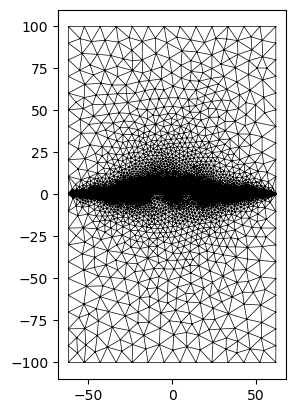

In [14]:
fig = mesh.draw()
fig.axes.set_axis_on()

In [15]:
idx_freq = -1
print(f"Frequency:{freq[idx_freq].magnitude:.2f} GHz")

basis0 = Basis(mesh, ElementTriP0(), intorder=4)  # Define the basis for the FEM
epsilon = basis0.ones(dtype=complex)

epsilon[basis0.get_dofs(elements="air")] = 1
epsilon[basis0.get_dofs(elements="substrate")] = eps_r_sub
epsilon[basis0.get_dofs(elements="metal_sig")] = (
    1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
)
epsilon[basis0.get_dofs(elements="metal_gnd_left")] = (
    1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
)
epsilon[basis0.get_dofs(elements="metal_gnd_right")] = (
    1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
)

Frequency:45.00 GHz


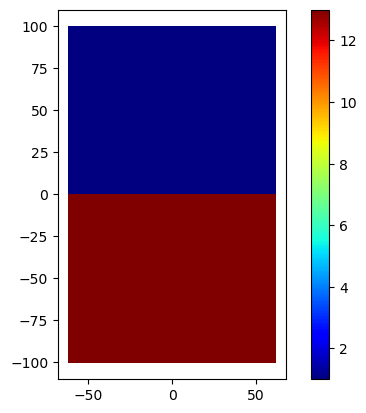

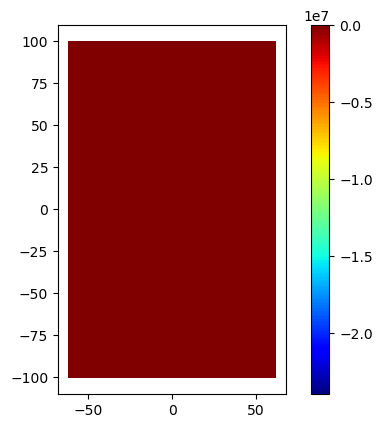

In [16]:
fig = basis0.plot(epsilon.real, colorbar=True)
fig.axes.set_axis_on()

fig = basis0.plot(epsilon.imag, colorbar=True)
fig.axes.set_axis_on()

In [17]:
start = time.time()
modes = compute_modes(
    basis0,
    epsilon,
    wavelength=(c / freq[idx_freq]).to(reg.micrometer).magnitude,
    num_modes=2,
    metallic_boundaries=False,
)
stop = time.time()

modes = modes.sorted(key=lambda mode: mode.n_eff.real)

print(stop - start)

10.954990148544312


In [18]:
print(modes.n_effs.real)
print(
    20
    / np.log(10)
    * (modes.n_effs.imag * 2 * np.pi * freq[idx_freq] / c).to(reg.centimeter**-1).magnitude,
    "dB/cm",
)

[2.61772304 2.63862014]
[-5.40691493 -1.8695633 ] dB/cm


In [19]:
from skfem import ElementDG, ElementTriP1, ElementVector

# Trying interpolator
Nx = 50
Ny = 50
grid_data_E = np.zeros((2, Ny, Nx, 3), dtype=complex)
grid_data_H = np.zeros((2, Ny, Nx, 3), dtype=complex)

xmin = -40
xmax = 40
ymin = -10
ymax = 10

grid_x, grid_y = np.meshgrid(np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny))

for i, mode in enumerate(modes):
    basis = mode.basis
    basis_fix = basis.with_element(ElementVector(ElementDG(ElementTriP1())))

    (et, et_basis), (ez, ez_basis) = basis.split(mode.E)
    (et_x, et_x_basis), (et_y, et_y_basis) = basis_fix.split(
        basis_fix.project(et_basis.interpolate(et))
    )

    coordinates = np.array([grid_x.flatten(), grid_y.flatten()])

    start = time.time()
    grid_data = np.array(
        (
            et_x_basis.interpolator(et_x)(coordinates),
            et_y_basis.interpolator(et_y)(coordinates),
            ez_basis.interpolator(ez)(coordinates),
        )
    ).T

    grid_data_E[i] = grid_data.reshape((*grid_x.shape, -1))
    end = time.time()
    print(end - start)

    (et, et_basis), (ez, ez_basis) = basis.split(mode.H)
    (et_x, et_x_basis), (et_y, et_y_basis) = basis_fix.split(
        basis_fix.project(et_basis.interpolate(et))
    )

    coordinates = np.array([grid_x.flatten(), grid_y.flatten()])

    grid_data = np.array(
        (
            et_x_basis.interpolator(et_x)(coordinates),
            et_y_basis.interpolator(et_y)(coordinates),
            ez_basis.interpolator(ez)(coordinates),
        )
    ).T

    grid_data_H[i] = grid_data.reshape((*grid_x.shape, -1))

C:\Users\blow\AppData\Local\anaconda3\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


1.2651357650756836
0.7790176868438721


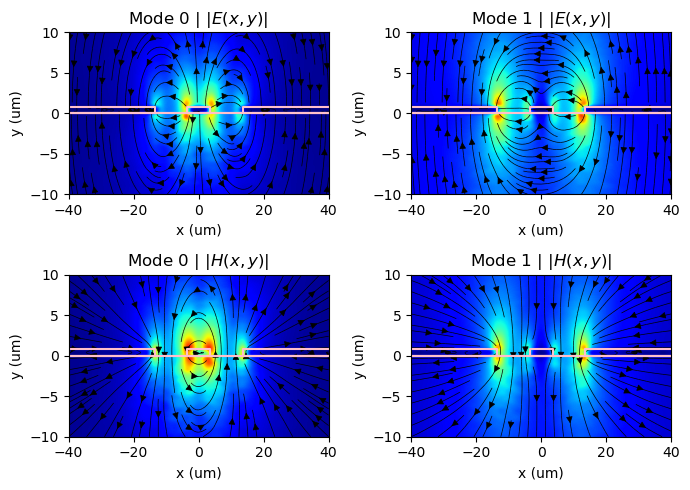

In [22]:
fig = plt.figure(figsize=(7, 5))
gs = GridSpec(2, 2)

ax_even_E = fig.add_subplot(gs[0, 0])
ax_odd_E = fig.add_subplot(gs[0, 1])

ax_even_H = fig.add_subplot(gs[1, 0])
ax_odd_H = fig.add_subplot(gs[1, 1])

for ax, data, label in zip(
    [ax_even_E, ax_odd_E, ax_even_H, ax_odd_H],
    [grid_data_E[0], grid_data_E[1], grid_data_H[0], grid_data_H[1]],
    [
        r"Mode 0 | $|E(x,y)|$",
        r"Mode 1 | $|E(x,y)|$",
        r"Mode 0 | $|H(x,y)|$",
        r"Mode 1 | $|H(x,y)|$",
    ],
):

    ax.imshow(
        np.sum(np.abs(data), axis=2),
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        cmap="jet",
        interpolation="bicubic",
        aspect="auto",
    )
    ax.streamplot(
        grid_x, grid_y, data.real[:, :, 0], data.real[:, :, 1], color="black", linewidth=0.5
    )

    for key, polygon in polygons.items():
        if type(polygon) is not LineString:
            x, y = polygon.exterior.xy
            ax.plot(np.asarray(x), np.asarray(y), color="pink")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")

    ax.set_title(label)

fig.tight_layout()
fig.savefig('modes.png', dpi = 400)

# Transmission line characterization

In [23]:
print(modes[0].transversality)
print(modes[1].transversality)

0.9999995080806268
0.9999997959671191


In [24]:
@Functional(dtype=np.complex64)
def current_form(w):
    """
    What this does is it takes the normal vector to the boundary and rotates it 90deg
    Then takes the inner product with the magnetic field in it's complex form
    """
    return inner(np.array([w.n[1], -w.n[0]]), w.H)


@Functional(dtype=np.complex64)
def voltage_form(w):
    """
    What this does is it takes the normal vector to the boundary and rotates it 90deg
    Then takes the inner product with the electric field in it's complex form
    """

    return -inner(np.array([w.n[1], -w.n[0]]), w.E)


conductor = "metal_sig_interface"
line = "path_integral_right"
mode = modes[0]

p0 = calculate_scalar_product(
    mode.basis, np.conjugate(mode.E), mode.basis, np.conjugate(mode.H)
)  # The conjugate is due to femwell internal definition as conj(E) x H


(ht, ht_basis), (hz, hz_basis) = mode.basis.split(mode.H)
facet_basis = ht_basis.boundary(facets=mesh.boundaries[conductor])
i0 = current_form.assemble(facet_basis, H=facet_basis.interpolate(ht))

(et, et_basis), (ez, ez_basis) = mode.basis.split(mode.E)
facet_basis = et_basis.boundary(facets=mesh.boundaries[line])
v0 = voltage_form.assemble(facet_basis, E=facet_basis.interpolate(et))


print(
    f"PI model : |Z0| = {np.abs(p0/np.abs(i0)**2):.2f} Ohm  |  angle(Z0) = {np.angle(p0/np.abs(i0)**2)/np.pi:.2f} pi radians"
)
print(
    f"PV model : |Z0| = {np.abs(np.abs(v0)**2/p0.conj()):.2f} Ohm  |  angle(Z0) = {np.angle(np.abs(v0)**2/p0.conj())/np.pi:.2f} pi radians"
)
print(
    f"VI model : |Z0| = {np.abs(v0/i0):.2f} Ohm  |  angle(Z0) = {np.angle(v0/i0)/np.pi:.2f} pi radians"
)

PI model : |Z0| = 61.77 Ohm  |  angle(Z0) = -0.01 pi radians
PV model : |Z0| = 60.19 Ohm  |  angle(Z0) = -0.01 pi radians
VI model : |Z0| = 60.97 Ohm  |  angle(Z0) = -0.00 pi radians


In [25]:
@Functional(dtype=np.complex64)
def C_form(w):

    return (
        1
        / np.abs(w.v0) ** 2
        * (
            np.real(w.epsilon) * inner(w.et, np.conj(w.et))
            - np.real(w.mu) * inner(w.hz, np.conj(w.hz))
        )
    )


@Functional(dtype=np.complex64)
def L_form(w):

    return (
        1
        / np.abs(w.i0) ** 2
        * (
            np.real(w.mu) * inner(w.ht, np.conj(w.ht))
            - np.real(w.epsilon) * inner(w.ez, np.conj(w.ez))
        )
    )


@Functional(dtype=np.complex64)
def G_form(w):
    # The minus sign account for the fact that in the paper they define eps = eps_r-1j*eps_i
    # whereas with python we have eps = eps_r+1j*eps_i.
    return (
        -w.omega
        / np.abs(w.v0) ** 2
        * (
            np.imag(w.epsilon) * inner(w.et, np.conj(w.et))
            + np.imag(w.mu) * inner(w.hz, np.conj(w.hz))
        )
    )


@Functional(dtype=np.complex64)
def R_form(w):
    # The minus sign account for the fact that in the paper they define eps = eps_r-1j*eps_i
    # whereas with python we have eps = eps_r+1j*eps_i.
    return (
        -w.omega
        / np.abs(w.i0) ** 2
        * (
            np.imag(w.epsilon) * inner(w.ez, np.conj(w.ez))
            + np.imag(w.mu) * inner(w.ht, np.conj(w.ht))
        )
    )


basis_t = et_basis
basis_z = ez_basis
basis_eps = basis0

# Be careful with the units!!
# In this case just make sure you adjust the length unit to micrometers
# everything else can stay as is.

C = C_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

L = L_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

G = G_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

R = R_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

Z0 = np.sqrt(
    (R + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L)
    / (G + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C)
)

gamma = np.sqrt(
    (R + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L)
    * (G + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C)
)

print(
    f"PI model : |Z0| = {np.abs(p0/np.abs(i0)**2):.2f} Ohm  |  angle(Z0) = {np.angle(p0/np.abs(i0)**2)/np.pi:.2f} pi radians"
)
print(
    f"PV model : |Z0| = {np.abs(np.abs(v0)**2/p0.conj()):.2f} Ohm  |  angle(Z0) = {np.angle(np.abs(v0)**2/p0.conj())/np.pi:.2f} pi radians"
)
print(
    f"VI model : |Z0| = {np.abs(v0/i0):.2f} Ohm  |  angle(Z0) = {np.angle(v0/i0)/np.pi:.2f} pi radians"
)
print(f"RLGC     : |Z0| = {np.abs(Z0):.2f} Ohm  |  angle(Z0) = {np.angle(Z0)/np.pi:.2f} pi radians")

print("=================== RLGC ==================")
print(f"R = {R.real/1e-3:.2f} mOhm/um")
print(f"L = {L.real/1e-12:.2f} picoHenry/um")
print(f"G = {G.real/1e-12:.2f} picoSiemens/um")
print(f"C = {C.real/1e-15:.2f} femtoFarad/um")

print("================== propagation constant ===============")
print(f"beta : RLGC = {gamma.imag*1e6:.2f} 1/m    |   FEM = {mode.k.real*1e6:.2f} 1/m ")
print(f"alpha: RLGC = {gamma.real*1e6:.2f} 1/m    |   FEM = {-mode.k.imag*1e6:.2f} 1/m ")

PI model : |Z0| = 61.77 Ohm  |  angle(Z0) = -0.01 pi radians
PV model : |Z0| = 60.19 Ohm  |  angle(Z0) = -0.01 pi radians
VI model : |Z0| = 60.97 Ohm  |  angle(Z0) = -0.00 pi radians
RLGC     : |Z0| = 60.66 Ohm  |  angle(Z0) = -0.01 pi radians
=================== RLGC ==================
R = 7.78 mOhm/um
L = 0.54 picoHenry/um
G = 86.08 picoSiemens/um
C = 0.15 femtoFarad/um
================== propagation constant ===============
beta : RLGC = 2515.66 1/m    |   FEM = 2467.15 1/m 
alpha: RLGC = 64.14 1/m    |   FEM = 62.25 1/m 


In [26]:
######## Define FEM simulation ###########
use_symmetry_plane = True
symmetry_plane = box(0, -np.inf, np.inf, np.inf)

near_field_width = 50 * reg.micrometer
near_field_height = 10 * reg.micrometer
##########################################


metal_sig_box = box(
    -w_sig.to(reg.micrometer).magnitude / 2,
    0,
    w_sig.to(reg.micrometer).magnitude / 2,
    t_metal.to(reg.micrometer).magnitude,
)

metal_gnd_left_box = box(
    max(
        (-w_sig / 2 - sep - w_gnd).to(reg.micrometer).magnitude,
        -(port_width / 2).to(reg.micrometer).magnitude,
    ),
    0,
    (-w_sig / 2 - sep).to(reg.micrometer).magnitude,
    t_metal.to(reg.micrometer).magnitude,
)

metal_gnd_right_box = box(
    (w_sig / 2 + sep).to(reg.micrometer).magnitude,
    0,
    min(
        (w_sig / 2 + sep + w_gnd).to(reg.micrometer).magnitude,
        (port_width / 2).to(reg.micrometer).magnitude,
    ),
    t_metal.to(reg.micrometer).magnitude,
)


air_box = box(
    (-port_width / 2).to(reg.micrometer).magnitude,
    0,
    (port_width / 2).to(reg.micrometer).magnitude,
    top_height.to(reg.micrometer).magnitude,
)


substrate_box = box(
    (-port_width / 2).to(reg.micrometer).magnitude,
    -(bottom_height).to(reg.micrometer).magnitude,
    (port_width / 2).to(reg.micrometer).magnitude,
    0,
)

surface = unary_union([air_box, substrate_box])

##Make a line for a path integral
### Right conductor
xmin_1, ymin_1, xmax_1, ymax_1 = metal_sig_box.bounds
xmin_2, ymin_2, xmax_2, ymax_2 = metal_gnd_right_box.bounds

points = [
    ((xmax_1 + xmin_1) / 2, (ymax_1 + ymin_1) / 2),
    (xmax_1, (ymax_1 + ymin_1) / 2),
    (xmin_2, (ymax_2 + ymin_2) / 2),
    ((xmax_2 + xmin_2) / 2, (ymax_2 + ymin_2) / 2),
]

path_integral_right = LineString(points)

### left conductor
xmin_1, ymin_1, xmax_1, ymax_1 = metal_sig_box.bounds
xmin_2, ymin_2, xmax_2, ymax_2 = metal_gnd_left_box.bounds

points = [
    ((xmax_1 + xmin_1) / 2, (ymax_1 + ymin_1) / 2),
    (xmin_1, (ymax_1 + ymin_1) / 2),
    (xmax_2, (ymax_2 + ymin_2) / 2),
    ((xmax_2 + xmin_2) / 2, (ymax_2 + ymin_2) / 2),
]

path_integral_left = LineString(points)

polygons = OrderedDict(
    surface=LineString(surface.exterior),
    metal_sig_interface=LineString(
        clip_by_rect(
            metal_sig_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_sig.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    metal_gnd_left_interface=LineString(
        clip_by_rect(
            metal_gnd_left_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_gnd.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    metal_gnd_right_interface=LineString(
        clip_by_rect(
            metal_gnd_right_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_gnd.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    path_integral_right=path_integral_right,
    path_integral_left=path_integral_left,
    metal_sig=metal_sig_box,
    metal_gnd_left=metal_gnd_left_box,
    metal_gnd_right=metal_gnd_right_box,
    air=air_box,
    substrate=substrate_box,
)


if use_symmetry_plane:
    keys_to_pop = []
    for key, poly in polygons.items():
        if poly.intersects(symmetry_plane) and not symmetry_plane.contains(poly):
            poly_tmp = clip_by_rect(poly, *symmetry_plane.bounds)

            if type(poly_tmp) == MultiLineString:
                polygons[key] = linemerge(poly_tmp)

            elif poly_tmp.is_empty:
                keys_to_pop.append(key)
            else:
                polygons[key] = poly_tmp
        elif not poly.intersects(symmetry_plane):
            keys_to_pop.append(key)

    for key in keys_to_pop:
        polygons.pop(key)


# Add the boundary polygons so that you can set custom boundary conditions
surf_bounds = polygons["surface"].bounds

left = LineString([(surf_bounds[0], surf_bounds[1]), (surf_bounds[0], surf_bounds[3])])

bottom = LineString([(surf_bounds[0], surf_bounds[1]), (surf_bounds[2], surf_bounds[1])])

right = LineString([(surf_bounds[2], surf_bounds[1]), (surf_bounds[2], surf_bounds[3])])

top = LineString([(surf_bounds[0], surf_bounds[3]), (surf_bounds[2], surf_bounds[3])])

polygons["left"] = left
polygons["bottom"] = bottom
polygons["right"] = right
polygons["top"] = top

polygons.move_to_end("top", last=False)
polygons.move_to_end("right", last=False)
polygons.move_to_end("bottom", last=False)
polygons.move_to_end("left", last=False)

polygons.pop("surface")

resolutions = dict(
    metal_sig_interface={"resolution": 0.1, "distance": 10},
    metal_gnd_interface={"resolution": 0.5, "distance": 10},
    path_integral_right={"resolution": 0.2, "distance": 10},
    path_integral_left={"resolution": 0.2, "distance": 10},
    metal_sig={"resolution": 0.1, "distance": 0.1, "SizeMax": 0.1},
    metal_gnd_left={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
    metal_gnd_right={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
    left={"resolution": 10, "distance": 0.1},
    right={"resolution": 10, "distance": 0.1},
    top={"resolution": 10, "distance": 0.1},
    bottom={"resolution": 10, "distance": 0.1},
    air={"resolution": 10, "distance": 0.1},
    substrate={"resolution": 10, "distance": 1},
)

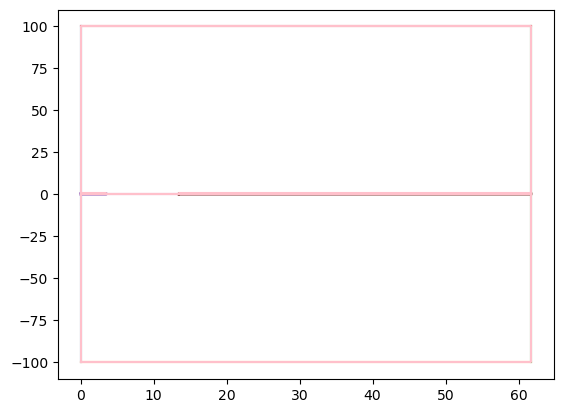

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

for key, polygon in polygons.items():
    # print(polygon)
    if type(polygon) is not LineString:
        x, y = polygon.exterior.xy
        ax.plot(np.asarray(x), np.asarray(y), color="pink")
    else:
        ax.plot(*polygon.xy)

In [28]:
# Mesh it
mesh = from_meshio(
    mesh_from_OrderedDict(polygons, resolutions, default_resolution_max=100, verbose=True)
)

<Axes: >

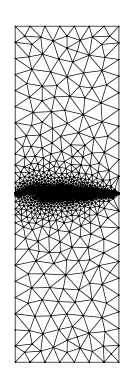

In [29]:
mesh.draw()

In [30]:
idx_freq = -1
print(f"Frequency:{freq[idx_freq].magnitude:.2f} GHz")

basis0 = Basis(mesh, ElementTriP0(), intorder=4)  # Define the basis for the FEM
epsilon = basis0.ones(dtype=complex)

epsilon[basis0.get_dofs(elements="air")] = 1
epsilon[basis0.get_dofs(elements="substrate")] = eps_r_sub
epsilon[basis0.get_dofs(elements="metal_sig")] = (
    1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
)
# epsilon[basis0.get_dofs(elements = 'metal_gnd_left')] = (1 - 1j*(sig_metal/omega/e0)[idx_freq].to(reg.dimensionless).magnitude)
epsilon[basis0.get_dofs(elements="metal_gnd_right")] = (
    1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
)

Frequency:45.00 GHz


In [31]:
start = time.time()
modes = compute_modes(
    basis0,
    epsilon,
    wavelength=(c / freq[idx_freq]).to(reg.micrometer).magnitude,
    num_modes=1,
    metallic_boundaries=[],
)

stop = time.time()

print(stop - start)

1.7470791339874268


In [32]:
print(modes.n_effs.real)
print(
    20
    / np.log(10)
    * (modes.n_effs.imag * 2 * np.pi * freq[idx_freq] / c).to(reg.centimeter**-1).magnitude,
    "dB/cm",
)

[2.61959773]
[-5.41859652] dB/cm


In [33]:
from skfem import ElementDG, ElementTriP1, ElementVector

# Trying interpolator
Nx = 25
Ny = 50
grid_data_E = np.zeros((len(modes), Ny, Nx, 3), dtype=complex)
grid_data_H = np.zeros((len(modes), Ny, Nx, 3), dtype=complex)

xmin = 0
xmax = 40
ymin = -10
ymax = 10

grid_x, grid_y = np.meshgrid(np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny))

for i, mode in enumerate(modes):
    basis = mode.basis
    basis_fix = basis.with_element(ElementVector(ElementDG(ElementTriP1())))

    (et, et_basis), (ez, ez_basis) = basis.split(mode.E)
    (et_x, et_x_basis), (et_y, et_y_basis) = basis_fix.split(
        basis_fix.project(et_basis.interpolate(et))
    )

    coordinates = np.array([grid_x.flatten(), grid_y.flatten()])

    start = time.time()
    grid_data = np.array(
        (
            et_x_basis.interpolator(et_x)(coordinates),
            et_y_basis.interpolator(et_y)(coordinates),
            ez_basis.interpolator(ez)(coordinates),
        )
    ).T

    grid_data_E[i] = grid_data.reshape((*grid_x.shape, -1))
    end = time.time()
    print(end - start)

    (et, et_basis), (ez, ez_basis) = basis.split(mode.H)
    (et_x, et_x_basis), (et_y, et_y_basis) = basis_fix.split(
        basis_fix.project(et_basis.interpolate(et))
    )

    coordinates = np.array([grid_x.flatten(), grid_y.flatten()])

    grid_data = np.array(
        (
            et_x_basis.interpolator(et_x)(coordinates),
            et_y_basis.interpolator(et_y)(coordinates),
            ez_basis.interpolator(ez)(coordinates),
        )
    ).T

    grid_data_H[i] = grid_data.reshape((*grid_x.shape, -1))

C:\Users\blow\AppData\Local\anaconda3\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


1.5764589309692383


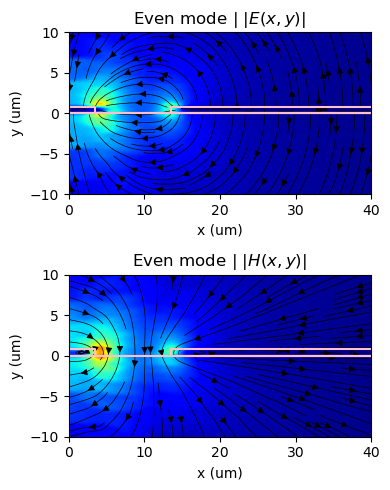

In [34]:
fig = plt.figure(figsize=(4, 5))
gs = GridSpec(2, 1)

ax_even_E = fig.add_subplot(gs[0, 0])
ax_even_H = fig.add_subplot(gs[1, 0])

mode_idx = 0
for ax, data, label in zip(
    [ax_even_E, ax_even_H],
    [grid_data_E[mode_idx], grid_data_H[mode_idx]],
    [r"Even mode | $|E(x,y)|$", r"Even mode | $|H(x,y)|$"],
):

    ax.imshow(
        np.sum(np.abs(data), axis=2),
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        cmap="jet",
        interpolation="bicubic",
        aspect="auto",
    )
    ax.streamplot(
        grid_x, grid_y, data.real[:, :, 0], data.real[:, :, 1], color="black", linewidth=0.5
    )

    for key, polygon in polygons.items():
        if type(polygon) is not LineString:
            x, y = polygon.exterior.xy
            ax.plot(np.asarray(x), np.asarray(y), color="pink")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")

    ax.set_title(label)

fig.tight_layout()
# fig.savefig('modes_sym.png', dpi = 400)

In [35]:
@Functional(dtype=np.complex64)
def current_form(w):
    """
    What this does is it takes the normal vector to the boundary and rotates it 90deg
    Then takes the inner product with the magnetic field in it's complex form
    """
    return inner(np.array([w.n[1], -w.n[0]]), w.H)


@Functional(dtype=np.complex64)
def voltage_form(w):
    """
    What this does is it takes the normal vector to the boundary and rotates it 90deg
    Then takes the inner product with the electric field in it's complex form
    """

    return -inner(np.array([w.n[1], -w.n[0]]), w.E)


conductor = "metal_sig_interface"
line = "path_integral_right"
mode = modes[0]

p0 = calculate_scalar_product(mode.basis, np.conjugate(mode.E), mode.basis, np.conjugate(mode.H))
print(p0)
# The conjugate is due to femwell internal definition as conj(E) x H
# The factor of 2 is to account for the fact that we are working with half the field only

(ht, ht_basis), (hz, hz_basis) = mode.basis.split(mode.H)
facet_basis = ht_basis.boundary(facets=mesh.boundaries[conductor])
i0 = current_form.assemble(facet_basis, H=facet_basis.interpolate(ht))

(et, et_basis), (ez, ez_basis) = mode.basis.split(mode.E)
facet_basis = et_basis.boundary(facets=mesh.boundaries[line])
v0 = voltage_form.assemble(facet_basis, E=facet_basis.interpolate(et))


v0 = p0 / i0.conj()
print(
    f"PI model : |Z0| = {np.abs(p0/np.abs(i0)**2):.2f} Ohm  |  angle(Z0) = {np.angle(p0/np.abs(i0)**2)/np.pi:.2f} pi radians"
)
print(
    f"PV model : |Z0| = {np.abs(np.abs(v0)**2/p0.conj()):.2f} Ohm  |  angle(Z0) = {np.angle(np.abs(v0)**2/p0.conj())/np.pi:.2f} pi radians"
)
print(
    f"VI model : |Z0| = {np.abs(v0/i0):.2f} Ohm  |  angle(Z0) = {np.angle(v0/i0)/np.pi:.2f} pi radians"
)

(1-0.023624858091574642j)
PI model : |Z0| = 124.67 Ohm  |  angle(Z0) = -0.01 pi radians
PV model : |Z0| = 124.67 Ohm  |  angle(Z0) = -0.01 pi radians
VI model : |Z0| = 124.67 Ohm  |  angle(Z0) = -0.01 pi radians


In [36]:
@Functional(dtype=np.complex64)
def C_form(w):

    return (
        1
        / np.abs(w.v0) ** 2
        * (
            np.real(w.epsilon) * inner(w.et, np.conj(w.et))
            - np.real(w.mu) * inner(w.hz, np.conj(w.hz))
        )
    )


@Functional(dtype=np.complex64)
def L_form(w):

    return (
        1
        / np.abs(w.i0) ** 2
        * (
            np.real(w.mu) * inner(w.ht, np.conj(w.ht))
            - np.real(w.epsilon) * inner(w.ez, np.conj(w.ez))
        )
    )


@Functional(dtype=np.complex64)
def G_form(w):
    # The minus sign account for the fact that in the paper they define eps = eps_r-1j*eps_i
    # whereas with python we have eps = eps_r+1j*eps_i.
    return (
        -w.omega
        / np.abs(w.v0) ** 2
        * (
            np.imag(w.epsilon) * inner(w.et, np.conj(w.et))
            + np.imag(w.mu) * inner(w.hz, np.conj(w.hz))
        )
    )


@Functional(dtype=np.complex64)
def R_form(w):
    # The minus sign account for the fact that in the paper they define eps = eps_r-1j*eps_i
    # whereas with python we have eps = eps_r+1j*eps_i.
    return (
        -w.omega
        / np.abs(w.i0) ** 2
        * (
            np.imag(w.epsilon) * inner(w.ez, np.conj(w.ez))
            + np.imag(w.mu) * inner(w.ht, np.conj(w.ht))
        )
    )


basis_t = et_basis
basis_z = ez_basis
basis_eps = basis0

# Be careful with the units!!
# In this case just make sure you adjust the length unit to micrometers
# everything else can stay as is.

C = C_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

L = L_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

G = G_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

R = R_form.assemble(
    mode.basis,
    epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
    mu=mu0.to(reg.henry / reg.micrometer).magnitude,
    i0=i0,
    omega=omega[idx_freq].to(reg.second**-1).magnitude,
    v0=v0,
    et=basis_t.interpolate(et),
    ez=basis_z.interpolate(ez),
    ht=basis_t.interpolate(ht),
    hz=basis_z.interpolate(hz),
)

Z0 = np.sqrt(
    (R + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L)
    / (G + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C)
)

gamma = np.sqrt(
    (R + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L)
    * (G + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C)
)

print(
    f"PI model : |Z0| = {np.abs(p0/np.abs(i0)**2):.2f} Ohm  |  angle(Z0) = {np.angle(p0/np.abs(i0)**2)/np.pi:.2f} pi radians"
)
print(
    f"PV model : |Z0| = {np.abs(np.abs(v0)**2/p0.conj()):.2f} Ohm  |  angle(Z0) = {np.angle(np.abs(v0)**2/p0.conj())/np.pi:.2f} pi radians"
)
print(
    f"VI model : |Z0| = {np.abs(v0/i0):.2f} Ohm  |  angle(Z0) = {np.angle(v0/i0)/np.pi:.2f} pi radians"
)
print(f"RLGC     : |Z0| = {np.abs(Z0):.2f} Ohm  |  angle(Z0) = {np.angle(Z0)/np.pi:.2f} pi radians")

print("=================== RLGC ==================")
print(f"R = {R.real/1e-3:.2f} mOhm/um")
print(f"L = {L.real/1e-12:.2f} picoHenry/um")
print(f"G = {G.real/1e-12:.2f} picoSiemens/um")
print(f"C = {C.real/1e-15:.2f} femtoFarad/um")

print("================== propagation constant ===============")
print(f"beta : RLGC = {gamma.imag*1e6:.2f} 1/m    |   FEM = {mode.k.real*1e6:.2f} 1/m ")
print(f"alpha: RLGC = {gamma.real*1e6:.2f} 1/m    |   FEM = {-mode.k.imag*1e6:.2f} 1/m ")

PI model : |Z0| = 124.67 Ohm  |  angle(Z0) = -0.01 pi radians
PV model : |Z0| = 124.67 Ohm  |  angle(Z0) = -0.01 pi radians
VI model : |Z0| = 124.67 Ohm  |  angle(Z0) = -0.01 pi radians
RLGC     : |Z0| = 123.13 Ohm  |  angle(Z0) = -0.01 pi radians
=================== RLGC ==================
R = 15.97 mOhm/um
L = 1.09 picoHenry/um
G = 41.85 picoSiemens/um
C = 0.07 femtoFarad/um
================== propagation constant ===============
beta : RLGC = 2504.06 1/m    |   FEM = 2468.91 1/m 
alpha: RLGC = 64.87 1/m    |   FEM = 62.38 1/m 


In [37]:
R = R / 2
L = L / 2
C = 2 * C
G = 2 * G

Z0 = np.sqrt(
    (R + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L)
    / (G + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C)
)

gamma = np.sqrt(
    (R + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L)
    * (G + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C)
)

print(f"RLGC     : |Z0| = {np.abs(Z0):.2f} Ohm  |  angle(Z0) = {np.angle(Z0)/np.pi:.2f} pi radians")

print("=================== RLGC ==================")
print(f"R = {R.real/1e-3:.2f} mOhm/um")
print(f"L = {L.real/1e-12:.2f} picoHenry/um")
print(f"G = {G.real/1e-12:.2f} picoSiemens/um")
print(f"C = {C.real/1e-15:.2f} femtoFarad/um")

print("================== propagation constant ===============")
print(f"beta : RLGC = {gamma.imag*1e6:.2f} 1/m    |   FEM = {mode.k.real*1e6:.2f} 1/m ")
print(f"alpha: RLGC = {gamma.real*1e6:.2f} 1/m    |   FEM = {-mode.k.imag*1e6:.2f} 1/m ")

RLGC     : |Z0| = 61.56 Ohm  |  angle(Z0) = -0.01 pi radians
=================== RLGC ==================
R = 7.98 mOhm/um
L = 0.54 picoHenry/um
G = 83.69 picoSiemens/um
C = 0.14 femtoFarad/um
================== propagation constant ===============
beta : RLGC = 2504.06 1/m    |   FEM = 2468.91 1/m 
alpha: RLGC = 64.87 1/m    |   FEM = 62.38 1/m 


In [38]:
reg = UnitRegistry()

use_symmetry_plane = True
mesh_res = "fine"

# Define frequency range
freq = np.logspace(np.log10(0.05), np.log10(45), 100) * reg.GHz
n_modes = 1
omega = 2 * np.pi * freq
print("meshing")


################## MESHING ################################
## Define universal constants
mu0 = 4 * np.pi * 1e-7 * reg.henry / reg.meter  # vacuum magnetic permeability
e0 = 8.854e-12 * reg.farad * reg.meter**-1
c = 3e8 * reg.meter * reg.second**-1  # m s^-1
e = 1.602176634e-19 * reg.coulomb  # Coulombs
kb = 1.380649e-23 * reg.meter**2 * reg.kg * reg.second**-2 * reg.kelvin**-1
T = 300 * reg.kelvin

w_sig = 7 * reg.micrometer
sep = 10 * reg.micrometer
w_gnd = 100 * reg.micrometer
t_metal = 0.8 * reg.micrometer

h_sub = 500 * reg.micrometer
h_air = 500 * reg.micrometer

eps_r_sub = 13 * reg.dimensionless

sig_metal = 6e5 * reg.siemens / reg.centimeter

######## Define FEM simulation ###########

symmetry_plane = box(0, -np.inf, np.inf, np.inf)
port_width = (w_sig + 2 * sep) * 3  # um
bottom_height = (w_sig + 2 * sep) * 1
top_height = (w_sig + 2 * sep) * 1

##########################################

metal_sig_box = box(
    -w_sig.to(reg.micrometer).magnitude / 2,
    0,
    w_sig.to(reg.micrometer).magnitude / 2,
    t_metal.to(reg.micrometer).magnitude,
)

metal_gnd_left_box = box(
    max(
        (-w_sig / 2 - sep - w_gnd).to(reg.micrometer).magnitude,
        -(port_width / 2).to(reg.micrometer).magnitude,
    ),
    0,
    (-w_sig / 2 - sep).to(reg.micrometer).magnitude,
    t_metal.to(reg.micrometer).magnitude,
)

metal_gnd_right_box = box(
    (w_sig / 2 + sep).to(reg.micrometer).magnitude,
    0,
    min(
        (w_sig / 2 + sep + w_gnd).to(reg.micrometer).magnitude,
        (port_width / 2).to(reg.micrometer).magnitude,
    ),
    t_metal.to(reg.micrometer).magnitude,
)

air_box = box(
    (-port_width / 2).to(reg.micrometer).magnitude,
    0,
    (port_width / 2).to(reg.micrometer).magnitude,
    top_height.to(reg.micrometer).magnitude,
)


substrate_box = box(
    (-port_width / 2).to(reg.micrometer).magnitude,
    -(bottom_height).to(reg.micrometer).magnitude,
    (port_width / 2).to(reg.micrometer).magnitude,
    0,
)

surface = unary_union([air_box, substrate_box])

##Make a line for a path integral
### Right conductor
xmin_1, ymin_1, xmax_1, ymax_1 = metal_sig_box.bounds
xmin_2, ymin_2, xmax_2, ymax_2 = metal_gnd_right_box.bounds

points = [
    ((xmax_1 + xmin_1) / 2, (ymax_1 + ymin_1) / 2),
    (xmax_1, (ymax_1 + ymin_1) / 2),
    (xmin_2, (ymax_2 + ymin_2) / 2),
    ((xmax_2 + xmin_2) / 2, (ymax_2 + ymin_2) / 2),
]

path_integral_right = LineString(points)

### left conductor
xmin_1, ymin_1, xmax_1, ymax_1 = metal_sig_box.bounds
xmin_2, ymin_2, xmax_2, ymax_2 = metal_gnd_left_box.bounds

points = [
    ((xmax_1 + xmin_1) / 2, (ymax_1 + ymin_1) / 2),
    (xmin_1, (ymax_1 + ymin_1) / 2),
    (xmax_2, (ymax_2 + ymin_2) / 2),
    ((xmax_2 + xmin_2) / 2, (ymax_2 + ymin_2) / 2),
]

path_integral_left = LineString(points)

polygons = OrderedDict(
    surface=LineString(surface.exterior),
    metal_sig_interface=LineString(
        clip_by_rect(
            metal_sig_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_sig.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    metal_gnd_left_interface=LineString(
        clip_by_rect(
            metal_gnd_left_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_gnd.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    metal_gnd_right_interface=LineString(
        clip_by_rect(
            metal_gnd_right_box.buffer(
                min(t_metal.to(reg.um).magnitude / 20, w_gnd.to(reg.um).magnitude / 10),
                join_style="bevel",
            ),
            *surface.bounds,
        ).exterior
    ),
    path_integral_right=path_integral_right,
    path_integral_left=path_integral_left,
    metal_sig=metal_sig_box,
    metal_gnd_left=metal_gnd_left_box,
    metal_gnd_right=metal_gnd_right_box,
    air=air_box,
    substrate=substrate_box,
)


if use_symmetry_plane:
    keys_to_pop = []
    for key, poly in polygons.items():
        if poly.intersects(symmetry_plane) and not symmetry_plane.contains(poly):
            poly_tmp = clip_by_rect(poly, *symmetry_plane.bounds)

            if type(poly_tmp) == MultiLineString:
                polygons[key] = linemerge(poly_tmp)

            elif poly_tmp.is_empty:
                keys_to_pop.append(key)
            else:
                polygons[key] = poly_tmp
        elif not poly.intersects(symmetry_plane):
            keys_to_pop.append(key)

    for key in keys_to_pop:
        polygons.pop(key)

# Add the boundary polygons so that you can set custom boundary conditions
surf_bounds = polygons["surface"].bounds

left = LineString([(surf_bounds[0], surf_bounds[1]), (surf_bounds[0], surf_bounds[3])])

bottom = LineString([(surf_bounds[0], surf_bounds[1]), (surf_bounds[2], surf_bounds[1])])

right = LineString([(surf_bounds[2], surf_bounds[1]), (surf_bounds[2], surf_bounds[3])])

top = LineString([(surf_bounds[0], surf_bounds[3]), (surf_bounds[2], surf_bounds[3])])

polygons["left"] = left
polygons["bottom"] = bottom
polygons["right"] = right
polygons["top"] = top

polygons.move_to_end("top", last=False)
polygons.move_to_end("right", last=False)
polygons.move_to_end("bottom", last=False)
polygons.move_to_end("left", last=False)

polygons.pop("surface")
# print(polygons.keys())
if mesh_res == "fine":
    resolutions = dict(
        surface={"resolution": 100, "distance": 1},
        metal_sig_interface={"resolution": 0.1, "distance": 10},
        metal_gnd_interface={"resolution": 0.5, "distance": 10},
        path_integral_right={"resolution": 0.2, "distance": 10},
        path_integral_left={"resolution": 0.2, "distance": 10},
        metal_sig={"resolution": 0.1, "distance": 0.1, "SizeMax": 0.1},
        metal_gnd_left={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
        metal_gnd_right={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
        air={"resolution": 10, "distance": 0.1},
        substrate={"resolution": 10, "distance": 1},
    )
else:
    resolutions = dict(
        surface={"resolution": 100, "distance": 1},
        metal_sig_interface={"resolution": 0.5, "distance": 10},
        metal_gnd_interface={"resolution": 0.5, "distance": 10},
        path_integral_right={"resolution": 0.5, "distance": 10},
        path_integral_left={"resolution": 0.5, "distance": 10},
        metal_sig={"resolution": 0.5, "distance": 0.1, "SizeMax": 0.1},
        metal_gnd_left={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
        metal_gnd_right={"resolution": 0.5, "distance": 0.2, "SizeMax": 0.5},
        air={"resolution": 20, "distance": 0.1},
        substrate={"resolution": 20, "distance": 1},
    )

# fig = plt.figure()
# ax = fig.add_subplot(111)

# for key, polygon in polygons.items():
#     if type(polygon) is not LineString:
#         x,y = polygon.exterior.xy
#         ax.plot(np.asarray(x),np.asarray(y), color = 'pink')
#     else:
#         ax.plot(*polygon.xy)
# Mesh it

meshing


In [39]:
mesh = from_meshio(
    mesh_from_OrderedDict(polygons, resolutions, default_resolution_max=100, verbose=True)
)

In [40]:
print(mesh.nelements)

11183


<Axes: >

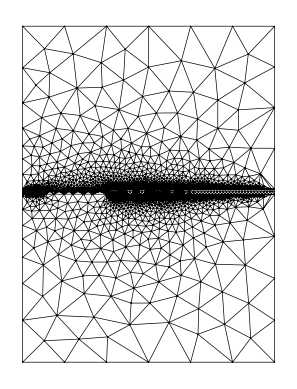

In [41]:
manager = enlighten.get_manager()
bar = manager.counter(total=len(freq), desc="Ticks", unit="ticks")

neff_all = np.zeros(len(freq), dtype=complex)
atten = np.zeros(len(freq), dtype=float)
z0 = np.zeros(len(freq), dtype=complex)
R = np.zeros(len(freq), dtype=complex)
L = np.zeros(len(freq), dtype=complex)
G = np.zeros(len(freq), dtype=complex)
C = np.zeros(len(freq), dtype=complex)
z0_RLGC = np.zeros(len(freq), dtype=complex)

for idx_freq in range(len(freq)):
    # break
    basis0 = Basis(mesh, ElementTriP0(), intorder=4)  # Define the basis for the FEM
    epsilon = basis0.ones(dtype=complex)

    epsilon[basis0.get_dofs(elements="air")] = 1
    epsilon[basis0.get_dofs(elements="substrate")] = eps_r_sub
    epsilon[basis0.get_dofs(elements="metal_sig")] = (
        1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
    )
    # epsilon[basis0.get_dofs(elements = 'metal_gnd_left')] = (1 - 1j*(sig_metal/omega/e0)[idx_freq].to(reg.dimensionless).magnitude)
    epsilon[basis0.get_dofs(elements="metal_gnd_right")] = (
        1 - 1j * (sig_metal / omega / e0)[idx_freq].to(reg.dimensionless).magnitude
    )
    # break
    modes = compute_modes(
        basis0,
        epsilon,
        wavelength=(c / freq[idx_freq]).to(reg.micrometer).magnitude,
        num_modes=n_modes,
        metallic_boundaries=False,
    )

    neff_all[idx_freq] = modes.n_effs
    atten[idx_freq] = (
        20
        / np.log(10)
        * (modes.n_effs.imag * 2 * np.pi * freq[idx_freq] / c).to(reg.centimeter**-1).magnitude
    )  # dB/cm

    ###### CALCULATE Z0 ############
    conductor = "metal_sig_interface"
    line = "path_integral_right"
    mode = modes[0]

    p0 = calculate_scalar_product(
        mode.basis, np.conjugate(mode.E), mode.basis, np.conjugate(mode.H)
    )  # The conjugate is due to femwell internal definition as conj(E) x H

    (ht, ht_basis), (hz, hz_basis) = mode.basis.split(mode.H)
    (et, et_basis), (ez, ez_basis) = mode.basis.split(mode.E)

    facet_basis = ht_basis.boundary(facets=mesh.boundaries[conductor])
    i0 = current_form.assemble(facet_basis, H=facet_basis.interpolate(ht))

    v0 = p0 / i0.conj()

    z0_tmp = v0 / i0

    ########### CALCULATE RLGC PARAMETERS #############
    basis_t = et_basis
    basis_z = ez_basis
    basis_eps = basis0

    C_tmp = C_form.assemble(
        mode.basis,
        epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
        mu=mu0.to(reg.henry / reg.micrometer).magnitude,
        i0=i0,
        omega=omega[idx_freq].to(reg.second**-1).magnitude,
        v0=v0,
        et=basis_t.interpolate(et),
        ez=basis_z.interpolate(ez),
        ht=basis_t.interpolate(ht),
        hz=basis_z.interpolate(hz),
    )

    L_tmp = L_form.assemble(
        mode.basis,
        epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
        mu=mu0.to(reg.henry / reg.micrometer).magnitude,
        i0=i0,
        omega=omega[idx_freq].to(reg.second**-1).magnitude,
        v0=v0,
        et=basis_t.interpolate(et),
        ez=basis_z.interpolate(ez),
        ht=basis_t.interpolate(ht),
        hz=basis_z.interpolate(hz),
    )

    G_tmp = G_form.assemble(
        mode.basis,
        epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
        mu=mu0.to(reg.henry / reg.micrometer).magnitude,
        i0=i0,
        omega=omega[idx_freq].to(reg.second**-1).magnitude,
        v0=v0,
        et=basis_t.interpolate(et),
        ez=basis_z.interpolate(ez),
        ht=basis_t.interpolate(ht),
        hz=basis_z.interpolate(hz),
    )

    R_tmp = R_form.assemble(
        mode.basis,
        epsilon=basis_eps.interpolate(epsilon * e0.to(reg.farad / reg.micrometer).magnitude),
        mu=mu0.to(reg.henry / reg.micrometer).magnitude,
        i0=i0,
        omega=omega[idx_freq].to(reg.second**-1).magnitude,
        v0=v0,
        et=basis_t.interpolate(et),
        ez=basis_z.interpolate(ez),
        ht=basis_t.interpolate(ht),
        hz=basis_z.interpolate(hz),
    )

    z0_RLGC_tmp = np.sqrt(
        (R_tmp + 1j * omega[idx_freq].to(reg.second**-1).magnitude * L_tmp)
        / (G_tmp + 1j * omega[idx_freq].to(reg.second**-1).magnitude * C_tmp)
    )

    ## Save the parameters for the full device

    z0[idx_freq] = z0_tmp / 2
    z0_RLGC[idx_freq] = z0_RLGC_tmp / 2
    R[idx_freq] = R_tmp / 2
    L[idx_freq] = L_tmp / 2
    G[idx_freq] = G_tmp * 2
    C[idx_freq] = C_tmp * 2

    bar.update()

mesh.draw()

# fig = basis0.plot(epsilon.real, colorbar = True)
# fig.axes.set_axis_on()

# fig = basis0.plot(epsilon.imag, colorbar = True)
# fig.axes.set_axis_on()

In [42]:
##DATA FROM PAPER
data_nu = np.asarray(
    [
        [-1.317, 7.780],
        [-1.218, 7.327],
        [-1.106, 6.474],
        [-0.983, 5.995],
        [-0.800, 5.160],
        [-0.647, 4.574],
        [-0.499, 4.094],
        [-0.270, 3.632],
        [0.000, 3.188],
        [0.311, 2.993],
        [0.622, 2.940],
        [0.958, 2.833],
        [1.254, 2.833],
        [1.559, 2.833],
    ]
)


data_alpha = np.asarray(
    [
        [-1.287, 0.728],
        [-1.060, 0.950],
        [-0.780, 1.181],
        [-0.520, 1.465],
        [-0.270, 1.785],
        [-0.025, 2.087],
        [0.204, 2.353],
        [0.392, 2.567],
        [0.632, 2.886],
        [0.846, 3.117],
        [1.070, 3.739],
        [1.310, 4.680],
        [1.478, 5.426],
        [1.590, 5.977],
    ]
)

## DATA FROM TU DELFT SIM
freq_matlab = np.loadtxt("support/freq_delft.txt")  # Frequency sampling from their simulator
ReZ0_delft = np.loadtxt("support/ReZ0_delft.txt")  # Real part of the impedance
ImZ0_delft = np.loadtxt("support/ImZ0_delft.txt")  # Imaginary part of the impedance
loss_delft = np.loadtxt("support/loss_delft.txt")  # The loss of the mode
ReK_delft = np.loadtxt("support/ReK_delft.txt")  # The real part of the wavevector

C:\Users\blow\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1340: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)
C:\Users\blow\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


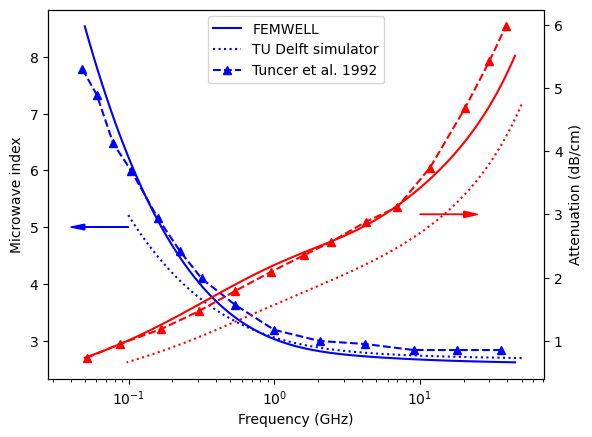

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax1 = ax.twinx()

ax.plot(freq, neff_all, color="blue", label="FEMWELL")
ax.plot(freq_matlab, ReK_delft, color="blue", linestyle="dotted", label="TU Delft simulator")

ax.plot(
    10 ** data_nu[:, 0],
    data_nu[:, 1],
    marker="^",
    color="blue",
    linestyle="dashed",
    label="Tuncer et al. 1992",
)
ax.set_xscale("log")

ax.legend(loc="upper center")
ax1.plot(freq, -atten, color="red")
ax1.plot(10 ** data_alpha[:, 0], data_alpha[:, 1], marker="^", color="red", linestyle="dashed")
ax1.plot(freq_matlab, loss_delft, color="red", linestyle="dotted")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Microwave index")
ax1.set_ylabel("Attenuation (dB/cm)")

ax.arrow(0.1, 5, -0.05, 0, head_width=0.1, head_length=0.01, color="blue")
ax1.arrow(10, 3, 10, 0, head_width=0.1, head_length=5, color="red")

# fig.savefig('Tuncer_et_al_1992_results.png', dpi = 400)

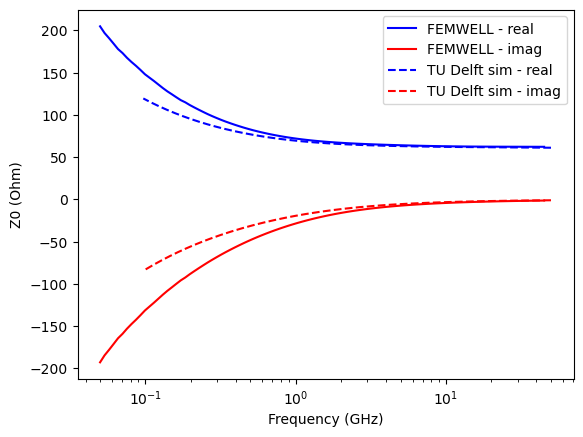

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(freq, z0.real, label="FEMWELL - real", color="blue")
ax.plot(freq, z0.imag, label="FEMWELL - imag", color="red")
ax.plot(freq_matlab, ReZ0_delft, label="TU Delft sim - real", color="blue", linestyle="dashed")
ax.plot(freq_matlab, ImZ0_delft, label="TU Delft sim - imag", color="red", linestyle="dashed")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Z0 (Ohm)")

ax.legend()

ax.set_xscale("log")

# fig.savefig('z0_delft.png', dpi = 400)

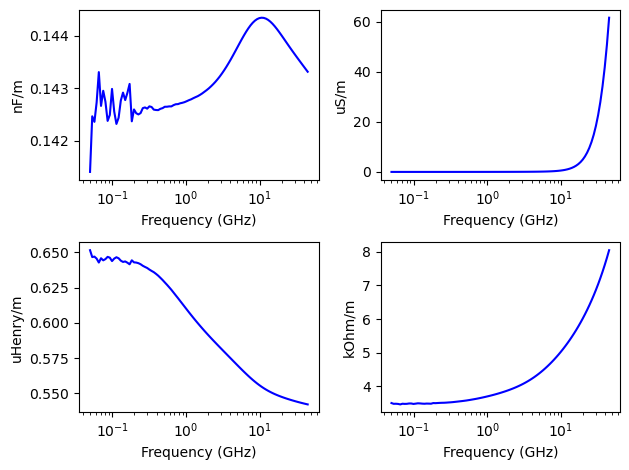

In [45]:
fig = plt.figure()
gs = GridSpec(2, 2)

ax_C = fig.add_subplot(gs[0, 0])
ax_G = fig.add_subplot(gs[0, 1])
ax_L = fig.add_subplot(gs[1, 0])
ax_R = fig.add_subplot(gs[1, 1])

for data, ax, label in zip(
    [R / 1e-3, L / 1e-12, G / 1e-12, C / 1e-15],
    [ax_R, ax_L, ax_G, ax_C],
    ["kOhm/m", "uHenry/m", "uS/m", "nF/m"],
):

    ax.plot(freq, data, color="blue")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel(label)

    ax.set_xscale("log")
fig.tight_layout()

In [ ]:
# Bibliography
# [1] E. Tuncer, Beom-Taek Lee, M.S. Islam, and D.P. Neikirk. Quasi-static conductor loss calculations in transmission lines using a new conformal mapping technique. IEEE Transactions on Microwave Theory and Techniques, 42(9):1807–1815, 1994. URL: http://dx.doi.org/10.1109/22.310592, doi:10.1109/22.310592.

# [2] G.W. Slade and K.J. Webb. Computation of characteristic impedance for multiple microstrip transmission lines using a vector finite element method. IEEE Transactions on Microwave Theory and Techniques, 40(1):34–40, 1992. URL: http://dx.doi.org/10.1109/22.108320, doi:10.1109/22.108320.

# [3] S. van Berkel, A. Garufo, A. Endo, N. LLombart, and A. Neto. Characterization of printed transmission lines at high frequencies. In The 9th European Conference on Antennas and Propagation (EuCAP 2015). The 9th European Conference on Antennas and Propagation (EuCAP 2015), 4 2015. URL: https://terahertz.tudelft.nl/Research/project.php?id=74\&ti=27.

# [4](1,2,3,4) R.B. Marks and D.F. Williams. A general waveguide circuit theory. Journal of Research of the National Institute of Standards and Technology, 97(5):533, September 1992. URL: http://dx.doi.org/10.6028/jres.097.024, doi:10.6028/jres.097.024.

# [5](1,2) D.F. Williams, L.A. Hayden, and R.B. Marks. A complete multimode equivalent-circuit theory for electrical design. Journal of Research of the National Institute of Standards and Technology, 102(4):405, July 1997. URL: http://dx.doi.org/10.6028/jres.102.029, doi:10.6028/jres.102.029.